In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as scip
import sklearn as sk

BLACK HOLE BINARY FORMATION CHANNELS WITH GAUSSIAN MIXTURE

Plotting the data

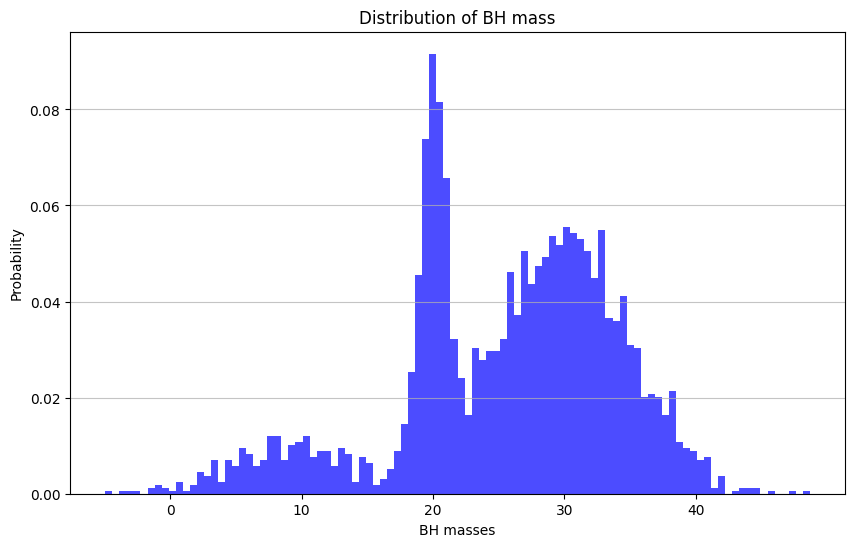

In [3]:
data = np.array(np.load('formationchannels.npy', allow_pickle=True))

plt.figure(figsize=(10, 6))
plt.hist(data, bins=100, density=True, alpha=0.7, color='blue')
plt.xlabel('BH masses')
plt.ylabel('Probability')
plt.title('Distribution of BH mass')
plt.xticks(np.arange(0, 50, 10))
plt.grid(axis='y', alpha=0.75)
plt.show()

Considering different component to do gaussian fit

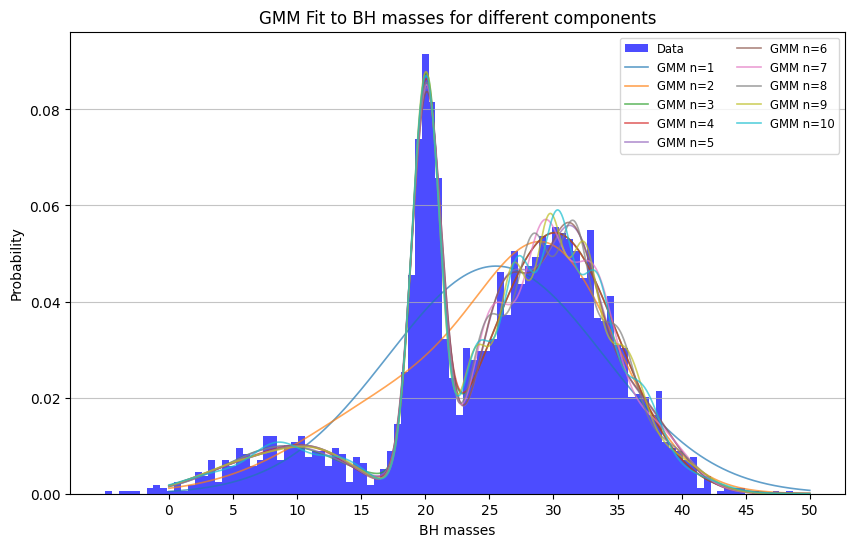

In [4]:
# Fit a Gaussian Mixture Model (GMM) to the data for different numbers of components
pdfs = []
for n in range(1, 11):
    # Model definition (instance of class)
    gmm = sk.mixture.GaussianMixture(n_components = n)

    # data has already been loades as a 2D array with shape (n_samples, 1) for sklearn
    gmm.fit(data)

    # Create a range of x values for plotting the GMM fit
    x = np.linspace(0, 50, 1000).reshape(-1, 1)

    # .score_samples returns the log-likelihood of the samples
    log_pdf = gmm.score_samples(x)

    # Convert log-likelihood back to normal probability density
    pdf = np.exp(log_pdf)

    pdfs.append(pdf)


# Plot the histogram of the data and the GMM fit(s)
plt.figure(figsize=(10, 6))
plt.hist(data, bins=100, density=True, alpha=0.7, color='blue', label='Data')

# Plot each GMM pdf from pdfs (one curve per component count)
for n, pdf in enumerate(pdfs, start=1):
    plt.plot(x.ravel(), pdf, lw=1.2, alpha=0.7, label=f'GMM n={n}')

plt.xlabel('BH masses')
plt.ylabel('Probability')
plt.title('GMM Fit to BH masses for different components')
plt.xticks(np.arange(0, 51, 5))
plt.grid(axis='y', alpha=0.75)
plt.legend(ncol=2, fontsize='small')
plt.show()



Finding optimal component number with AIC

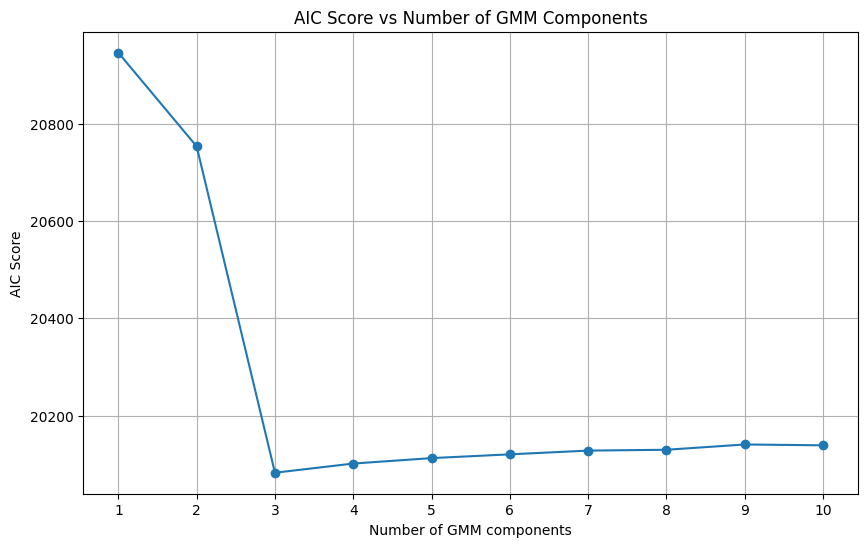

In [ ]:
#plot AIC score as function of N, to find the optimal number of components
#lower AIC is better, so we want to find the minimum AIC score
aic_scores = []
for n in range(1, 11):
    gmm = sk.mixture.GaussianMixture(n_components = n)
    gmm.fit(data)
    aic_scores.append(gmm.aic(data))
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), aic_scores, marker='o')
plt.xlabel('Number of GMM components')
plt.ylabel('AIC Score')
plt.title('AIC Score vs Number of GMM Components')
plt.xticks(range(1, 11))
plt.grid()
plt.show()


Plottin gaussian mixture fit with the best AIC

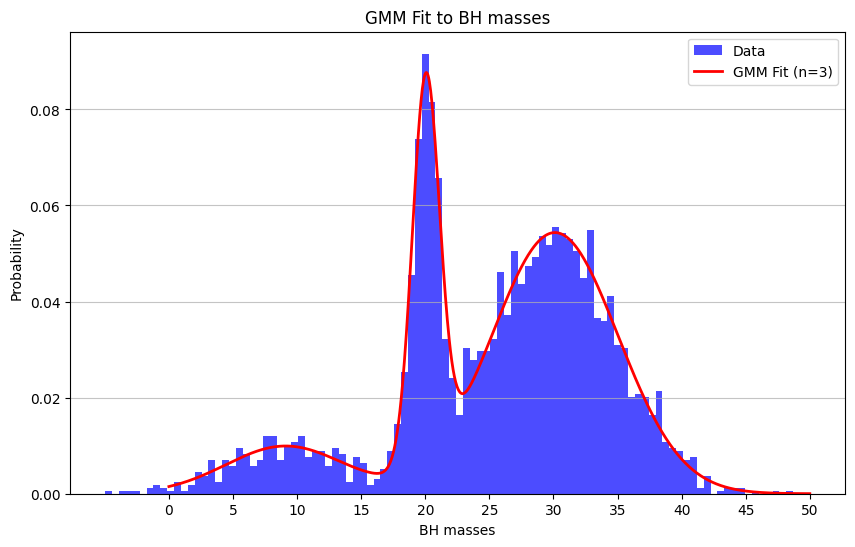

In [ ]:
# Fit a Gaussian Mixture Model (GMM) to the data for different numbers of components

best_aic = np.argmin(aic_scores) + 1  # +1 because index starts at 0
gmm = sk.mixture.GaussianMixture(n_components = best_aic)
# data has already been loades as a 2D array with shape (n_samples, 1)
gmm.fit(data)
# Create a range of x values for plotting the GMM fit
x = np.linspace(0, 50, 1000).reshape(-1, 1)
# .score_samples returns the log-likelihood of the samples
log_pdf = gmm.score_samples(x)
# Convert log-likelihood back to normal probability density
pdf = np.exp(log_pdf)

# Plot the histogram of the data and the GMM fit(s)
plt.figure(figsize=(10, 6))
plt.hist(data, bins=100, density=True, alpha=0.7, color='blue', label='Data')
plt.plot(x.ravel(), pdf, color='red', label=f'GMM Fit (n={best_aic})', lw=2)
plt.xlabel('BH masses')
plt.ylabel('Probability')
plt.title('GMM Fit to BH masses')
plt.xticks(np.arange(0, 51, 5))
plt.grid(axis='y', alpha=0.75)
plt.legend()
plt.show()  



